In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
from typing import Dict, List, Optional, Tuple, Any
import copy

warnings.filterwarnings('ignore')

def set_seeds(seed=42):
    """Set seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class MLPRegressor(nn.Module):
    """Multi-Layer Perceptron for regression"""
    def __init__(self, input_size: int, hidden_sizes: List[int], dropout_rate: float = 0.2):
        super(MLPRegressor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x):
        return self.network(x)

class MLPModelManager:
    """Main class for MLP regression with comprehensive features"""
    
    def __init__(self):
        self.model = None
        self.scaler_X = None
        self.scaler_y = None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.feature_names = None
        self.training_history = None
        self.X_test = None  # Store test set for plotting
        self.y_test = None
        self.feature_ranges = {}  # Store min/max for each feature
        self.target_range = {}  # Store min/max for target
        
        # Default parameter grid for tuning
        self.param_grid = {
            'hidden_sizes': [[64, 32], [128, 64], [64, 32, 16], [128, 64, 32]],
            'dropout_rate': [0.1, 0.2, 0.3],
            'learning_rate': [0.001, 0.01, 0.1],
            'batch_size': [32, 64, 128],
            'epochs': [100, 200, 500]
        }
        
        print(f"MLPModelManager initialized. Device: {self.device}")
    
    def load_data(self, csv_path: str, target_column: str, 
                  features_to_drop: Optional[List[str]] = None) -> Tuple[pd.DataFrame, pd.Series]:
        """Load data from CSV file"""
        print(f"Loading data from: {csv_path}")
        
        try:
            df = pd.read_csv(csv_path).round(2)
        except Exception as e:
            raise FileNotFoundError(f"Could not load CSV file: {e}")
        
        # Drop unwanted features
        if features_to_drop:
            available_features = [f for f in features_to_drop if f in df.columns]
            if available_features:
                df = df.drop(columns=available_features)
                print(f"Dropped features: {available_features}")
        
        # Check target column exists
        if target_column not in df.columns:
            raise ValueError(f"Target column '{target_column}' not found. Available columns: {list(df.columns)}")
        
        # Separate features and target
        X = df.drop(columns=[target_column])
        y = df[target_column]
        
        # Store feature names
        self.feature_names = list(X.columns)
        
        print(f"Dataset loaded successfully!")
        print(f"Features ({len(self.feature_names)}): {self.feature_names}")
        print(f"Target: {target_column}")
        print(f"Dataset shape: {X.shape}")
        print(f"Missing values - Features: {X.isnull().sum().sum()}, Target: {y.isnull().sum()}")
        
        # Store feature ranges from training data
        for col in X.columns:
            self.feature_ranges[col] = {
                'min': X[col].min(),
                'max': X[col].max(),
                'mean': X[col].mean(),
                'std': X[col].std()
            }
        
        # Store target range
        self.target_range = {
            'min': y.min(),
            'max': y.max(),
            'mean': y.mean(),
            'std': y.std()
        }
        
        print(f"\n📊 Feature Ranges Summary:")
        for feat, ranges in self.feature_ranges.items():
            print(f"   {feat}: [{ranges['min']:.2f}, {ranges['max']:.2f}]")
        print(f"   Target: [{self.target_range['min']:.2f}, {self.target_range['max']:.2f}]")
        
        return X, y
    
    def train_model(self, X: pd.DataFrame, y: pd.Series, params: Dict[str, Any],
                   k_folds: int = 5, early_stopping_patience: int = 20, 
                   test_split: float = 0.2) -> Dict[str, Any]:
        """Train MLP model with K-fold cross-validation"""
        
        print("\n" + "="*60)
        print("STARTING MODEL TRAINING")
        print("="*60)
        
        set_seeds(42)
        
        # Convert to numpy
        X_np = X.values.astype(np.float32)
        y_np = y.values.astype(np.float32).reshape(-1, 1)
        
        # Check for NaN values
        if np.isnan(X_np).any() or np.isnan(y_np).any():
            raise ValueError("Data contains NaN values. Please clean your data first.")
        
        # Train/Test split
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X_np, y_np, test_size=test_split, random_state=42, shuffle=True
        )
        
        print(f"Data split: Train+Val={len(X_trainval)}, Test={len(X_test)}")
        
        # Store test data immediately after split (before any potential errors)
        self.X_test = pd.DataFrame(X_test, columns=self.feature_names)
        self.y_test = pd.Series(y_test.flatten(), name='target')
        print(f"✅ Test data stored: {len(self.X_test)} samples")
        
        # Initialize results dictionary
        results = {
            'fold_results': [],
            'avg_cv_metrics': {},
            'final_train_metrics': {},
            'test_metrics': {},
            'overfitting_detected': False,
            'recommendations': [],
            'overfitting_indicators': []
        }
        
        # Initialize scalers (fit on training data only)
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self.scaler_X.fit(X_trainval)
        self.scaler_y.fit(y_trainval)
        
        print(f"Scalers fitted on training data")
        
        # K-fold cross-validation
        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        best_model_state = None
        best_val_r2 = -float('inf')
        
        print(f"\nStarting {k_folds}-fold cross-validation...")
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
            print(f"\nFold {fold + 1}/{k_folds}")
            print("-" * 30)
            
            # Split fold data
            X_train_fold = X_trainval[train_idx]
            X_val_fold = X_trainval[val_idx]
            y_train_fold = y_trainval[train_idx]
            y_val_fold = y_trainval[val_idx]
            
            # Scale data
            X_train_scaled = self.scaler_X.transform(X_train_fold)
            X_val_scaled = self.scaler_X.transform(X_val_fold)
            y_train_scaled = self.scaler_y.transform(y_train_fold)
            y_val_scaled = self.scaler_y.transform(y_val_fold)
            
            # Convert to tensors
            X_train_tensor = torch.FloatTensor(X_train_scaled).to(self.device)
            y_train_tensor = torch.FloatTensor(y_train_scaled).to(self.device)
            X_val_tensor = torch.FloatTensor(X_val_scaled).to(self.device)
            y_val_tensor = torch.FloatTensor(y_val_scaled).to(self.device)
            
            # Create data loader
            train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
            train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
            
            # Initialize model
            model = MLPRegressor(
                input_size=X_train_scaled.shape[1],
                hidden_sizes=params['hidden_sizes'],
                dropout_rate=params['dropout_rate']
            ).to(self.device)
            
            # Loss and optimizer
            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'])
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=10
            )
            
            # Training variables
            train_losses = []
            val_losses = []
            best_val_loss = float('inf')
            patience_counter = 0
            best_fold_model = None
            
            # Training loop
            for epoch in range(params['epochs']):
                # Training phase
                model.train()
                epoch_train_loss = 0.0
                
                for batch_X, batch_y in train_loader:
                    optimizer.zero_grad()
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    
                    # Gradient clipping
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    epoch_train_loss += loss.item()
                
                avg_train_loss = epoch_train_loss / len(train_loader)
                train_losses.append(avg_train_loss)
                
                # Validation phase
                model.eval()
                with torch.no_grad():
                    val_outputs = model(X_val_tensor)
                    val_loss = criterion(val_outputs, y_val_tensor).item()
                    val_losses.append(val_loss)
                
                # Learning rate scheduling
                scheduler.step(val_loss)
                
                # Early stopping
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    best_fold_model = copy.deepcopy(model.state_dict())
                else:
                    patience_counter += 1
                
                if patience_counter >= early_stopping_patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break
            
            # Load best model for this fold
            if best_fold_model is not None:
                model.load_state_dict(best_fold_model)
            
            # Evaluate fold performance
            model.eval()
            with torch.no_grad():
                # Training metrics
                train_pred_scaled = model(X_train_tensor).cpu().numpy()
                train_pred = self.scaler_y.inverse_transform(train_pred_scaled).flatten()
                train_actual = y_train_fold.flatten()
                
                train_r2 = r2_score(train_actual, train_pred)
                train_rmse = np.sqrt(mean_squared_error(train_actual, train_pred))
                train_mae = mean_absolute_error(train_actual, train_pred)
                
                # Validation metrics
                val_pred_scaled = model(X_val_tensor).cpu().numpy()
                val_pred = self.scaler_y.inverse_transform(val_pred_scaled).flatten()
                val_actual = y_val_fold.flatten()
                
                val_r2 = r2_score(val_actual, val_pred)
                val_rmse = np.sqrt(mean_squared_error(val_actual, val_pred))
                val_mae = mean_absolute_error(val_actual, val_pred)
            
            # Store fold results
            fold_result = {
                'fold': fold + 1,
                'train_r2': train_r2,
                'train_rmse': train_rmse,
                'train_mae': train_mae,
                'val_r2': val_r2,
                'val_rmse': val_rmse,
                'val_mae': val_mae,
                'epochs_trained': len(train_losses),
                'final_train_loss': train_losses[-1],
                'final_val_loss': val_losses[-1]
            }
            
            results['fold_results'].append(fold_result)
            
            print(f"Train: R²={train_r2:.4f}, RMSE={train_rmse:.4f}, MAE={train_mae:.4f}")
            print(f"Val:   R²={val_r2:.4f}, RMSE={val_rmse:.4f}, MAE={val_mae:.4f}")
            
            # Keep best model across all folds
            if val_r2 > best_val_r2:
                best_val_r2 = val_r2
                best_model_state = copy.deepcopy(model.state_dict())
                self.training_history = {'train_losses': train_losses, 'val_losses': val_losses}
        
        # Train final model on full training data
        print(f"\nTraining final model on full training set...")
        
        X_trainval_scaled = self.scaler_X.transform(X_trainval)
        y_trainval_scaled = self.scaler_y.transform(y_trainval)
        
        X_trainval_tensor = torch.FloatTensor(X_trainval_scaled).to(self.device)
        y_trainval_tensor = torch.FloatTensor(y_trainval_scaled).to(self.device)
        
        # Initialize final model
        self.model = MLPRegressor(
            input_size=X_trainval_scaled.shape[1],
            hidden_sizes=params['hidden_sizes'],
            dropout_rate=params['dropout_rate']
        ).to(self.device)
        
        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)
        
        # Final model evaluation on training set
        self.model.eval()
        with torch.no_grad():
            train_pred_scaled = self.model(X_trainval_tensor).cpu().numpy()
            train_pred = self.scaler_y.inverse_transform(train_pred_scaled).flatten()
            train_actual = y_trainval.flatten()
            
            final_train_r2 = r2_score(train_actual, train_pred)
            final_train_rmse = np.sqrt(mean_squared_error(train_actual, train_pred))
            final_train_mae = mean_absolute_error(train_actual, train_pred)
        
        # Test set evaluation
        print(f"Evaluating on test set...")
        X_test_scaled = self.scaler_X.transform(X_test)
        X_test_tensor = torch.FloatTensor(X_test_scaled).to(self.device)
        
        with torch.no_grad():
            test_pred_scaled = self.model(X_test_tensor).cpu().numpy()
            test_pred = self.scaler_y.inverse_transform(test_pred_scaled).flatten()
            test_actual = y_test.flatten()
            
            test_r2 = r2_score(test_actual, test_pred)
            test_rmse = np.sqrt(mean_squared_error(test_actual, test_pred))
            test_mae = mean_absolute_error(test_actual, test_pred)
        
        # Calculate average CV metrics
        results['avg_cv_metrics'] = {
            'train_r2_mean': np.mean([f['train_r2'] for f in results['fold_results']]),
            'train_r2_std': np.std([f['train_r2'] for f in results['fold_results']]),
            'val_r2_mean': np.mean([f['val_r2'] for f in results['fold_results']]),
            'val_r2_std': np.std([f['val_r2'] for f in results['fold_results']]),
            'train_rmse_mean': np.mean([f['train_rmse'] for f in results['fold_results']]),
            'val_rmse_mean': np.mean([f['val_rmse'] for f in results['fold_results']]),
            'train_mae_mean': np.mean([f['train_mae'] for f in results['fold_results']]),
            'val_mae_mean': np.mean([f['val_mae'] for f in results['fold_results']])
        }
        
        # Store final metrics
        results['final_train_metrics'] = {
            'r2': final_train_r2,
            'rmse': final_train_rmse,
            'mae': final_train_mae
        }
        
        results['test_metrics'] = {
            'r2': test_r2,
            'rmse': test_rmse,
            'mae': test_mae
        }
       
        
        # Analyze overfitting
        self._detect_overfitting(results)
        
        # Generate report
        self._generate_report(results, params)
        
        return results

    def plot_test_predictions(self, X_test, y_test):
        """Plot actual vs predicted values for test set"""
        print("\n=== Plotting Test Set Predictions ===")
        
        # Prepare test data
        X_test_scaled = self.scaler_X.transform(X_test)
        X_test_tensor = torch.FloatTensor(X_test_scaled).to(self.device)
        
        with torch.no_grad():
            test_pred_scaled = self.model(X_test_tensor).cpu().numpy()
            test_pred = self.scaler_y.inverse_transform(test_pred_scaled).flatten()
            test_actual = y_test.flatten()
            
            test_r2 = r2_score(test_actual, test_pred)
            test_rmse = np.sqrt(mean_squared_error(test_actual, test_pred))
        
        # Create single plot
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        ax.scatter(test_actual, test_pred, alpha=0.7, color='orange', label='Predictions')
        ax.plot([test_actual.min(), test_actual.max()], 
                [test_actual.min(), test_actual.max()], 
                'r--', lw=2, label='Perfect Prediction')
        ax.set_xlabel('Actual CCG Yield')
        ax.set_ylabel('Predicted CCG Yield')
        ax.set_title(f'Test Set: Actual vs Predicted\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return test_pred
    
    def _detect_overfitting(self, results: Dict) -> None:
        """Detect overfitting patterns and provide recommendations"""
        
        indicators = []
        recommendations = []
        
        # Check train-validation gap
        avg_train_r2 = results['avg_cv_metrics']['train_r2_mean']
        avg_val_r2 = results['avg_cv_metrics']['val_r2_mean']
        cv_gap = avg_train_r2 - avg_val_r2
        
        if cv_gap > 0.1:
            indicators.append(f"Large CV gap: Train R²({avg_train_r2:.3f}) - Val R²({avg_val_r2:.3f}) = {cv_gap:.3f}")
        
        # Check train-test gap
        final_train_r2 = results['final_train_metrics']['r2']
        test_r2 = results['test_metrics']['r2']
        train_test_gap = final_train_r2 - test_r2
        
        if train_test_gap > 0.1:
            indicators.append(f"Large train-test gap: {train_test_gap:.3f}")
        
        # Check validation variance
        val_r2_std = results['avg_cv_metrics']['val_r2_std']
        if val_r2_std > 0.1:
            indicators.append(f"High validation variance: {val_r2_std:.3f}")
        
        # Check loss divergence
        for fold_result in results['fold_results']:
            if fold_result['final_val_loss'] > fold_result['final_train_loss'] * 1.5:
                indicators.append("Validation loss >> Training loss in some folds")
                break
        
        # Set overfitting status
        if indicators:
            results['overfitting_detected'] = True
            results['overfitting_indicators'] = indicators
            
            recommendations = [
                "Increase dropout rate (0.3-0.5)",
                "Reduce model complexity",
                "Add L2 regularization",
                "Collect more training data",
                "Increase early stopping patience",
                "Try batch normalization"
            ]
            results['recommendations'] = recommendations
    
    def _generate_report(self, results: Dict, params: Dict) -> None:
        """Generate comprehensive training report"""
        
        print("\n" + "="*80)
        print("                      MLP REGRESSION MODEL REPORT")
        print("="*80)
        
        # Model Configuration
        print("\n📋 MODEL CONFIGURATION:")
        print(f"   Architecture: {params['hidden_sizes']}")
        print(f"   Dropout: {params['dropout_rate']}")
        print(f"   Learning Rate: {params['learning_rate']}")
        print(f"   Batch Size: {params['batch_size']}")
        print(f"   Max Epochs: {params['epochs']}")
        print(f"   Device: {self.device}")
        
        # Cross-validation results
        print(f"\n📊 {len(results['fold_results'])}-FOLD CROSS-VALIDATION:")
        print("-" * 70)
        print("Fold    Train R²   Train RMSE    Val R²    Val RMSE   Epochs")
        print("-" * 70)
        
        for fold in results['fold_results']:
            print(f"{fold['fold']:2d}      {fold['train_r2']:.4f}     {fold['train_rmse']:.4f}    "
                  f"{fold['val_r2']:.4f}    {fold['val_rmse']:.4f}    {fold['epochs_trained']:3d}")
        
        print("-" * 70)
        avg_metrics = results['avg_cv_metrics']
        print(f"Mean    {avg_metrics['train_r2_mean']:.4f}     {avg_metrics['train_rmse_mean']:.4f}    "
              f"{avg_metrics['val_r2_mean']:.4f}    {avg_metrics['val_rmse_mean']:.4f}")
        print(f"Std     {avg_metrics['train_r2_std']:.4f}        -         "
              f"{avg_metrics['val_r2_std']:.4f}        -")
        
        # Final performance
        print(f"\n🎯 FINAL PERFORMANCE:")
        train_metrics = results['final_train_metrics']
        test_metrics = results['test_metrics']
        
        print(f"   Training Set: R²={train_metrics['r2']:.4f}, "
              f"RMSE={train_metrics['rmse']:.4f}, MAE={train_metrics['mae']:.4f}")
        print(f"   Test Set:     R²={test_metrics['r2']:.4f}, "
              f"RMSE={test_metrics['rmse']:.4f}, MAE={test_metrics['mae']:.4f}")
        
        # Performance analysis
        train_test_gap = train_metrics['r2'] - test_metrics['r2']
        print(f"\n📈 PERFORMANCE ANALYSIS:")
        print(f"   Train-Test R² Gap: {train_test_gap:.4f}")
        
        if train_test_gap < 0.05:
            print("   ✅ Excellent generalization")
        elif train_test_gap < 0.1:
            print("   ⚠️  Moderate generalization")
        else:
            print("   ❌ Poor generalization - overfitting detected")
        
        # Overfitting analysis
        print(f"\n🔍 OVERFITTING ANALYSIS:")
        if results['overfitting_detected']:
            print("   Status: ⚠️  OVERFITTING DETECTED")
            print("   Indicators:")
            for indicator in results['overfitting_indicators']:
                print(f"      • {indicator}")
            print("   Recommendations:")
            for rec in results['recommendations']:
                print(f"      • {rec}")
        else:
            print("   Status: ✅ No significant overfitting")
        
        print("\n" + "="*80)
        print("Training completed successfully! ✨")
        print("="*80)

        
    
    def plot_feature_vs_target(self, X: pd.DataFrame, y: pd.Series,
                                feature_name: str,

                              dataset_type: str = 'test'):
        """Plot feature vs target with predictions
        
        Args:
            X: Feature data
            y: Target data  
            feature_name: Name of feature to plot
            dataset_type: 'test', 'train', or 'full' - determines which R² to show
        """
        
        if self.model is None:
            print("❌ No trained model found. Train the model first.")
            return
            
        if feature_name not in self.feature_names:
            print(f"❌ Feature '{feature_name}' not found.")
            print(f"Available features: {self.feature_names}")
            return
        
        # Make predictions on provided data
        X_scaled = self.scaler_X.transform(X.values)
        X_tensor = torch.FloatTensor(X_scaled).to(self.device)
        
        self.model.eval()
        with torch.no_grad():
            y_pred_scaled = self.model(X_tensor).cpu().numpy()
            y_pred = self.scaler_y.inverse_transform(y_pred_scaled).flatten()
        
        # Create plots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 16))
        # fig, axes = plt.subplots(1, 1, figsize=(10,8))

        # axes.scatter(self.y_test, self.y_test_pred, alpha=0.7, color='green', label='Predictions')
        # min_val = min(y.values.min(), y_pred.min())
        # max_val = max(y.values.max(), y_pred.max())
        # axes.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        # axes.set_xlabel('Actual CCG Yield')
        # axes.set_ylabel('Predicted CCG Yield')
        # axes.set_title(f'Test Set\nR² = {metrics["test_r2"]:.4f}, RMSE = {metrics["test_rmse"]:.4f}')
        # axes.legend()
        # axes.grid(True, alpha=0.3)
        
        # Plot 1: Feature vs Target
        feature_values = X[feature_name].values
        ax1.scatter(feature_values, y.values, alpha=0.6, label='Actual', color='blue', s=30)
        ax1.scatter(feature_values, y_pred, alpha=0.6, label='Predicted', color='red', s=30)
        ax1.set_xlabel(feature_name)
        ax1.set_ylabel('Target')
        ax1.set_title(f'{feature_name} vs Target ({dataset_type.title()} Data)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Actual vs Predicted
        ax2.scatter(y.values, y_pred, alpha=0.6, s=30)
        min_val = min(y.values.min(), y_pred.min())
        max_val = max(y.values.max(), y_pred.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)
        ax2.set_xlabel('Actual CCG Yield')
        ax2.set_ylabel('Predicted CCG Yield')
        # ax2.set_title(f'Actual vs Predicted ({dataset_type.title()} Data)')
        ax2.grid(True, alpha=0.3)
        
        # Calculate metrics for this specific data
        r2 = r2_score(y.values, y_pred)
        rmse = np.sqrt(mean_squared_error(y.values, y_pred))
        mae = mean_absolute_error(y.values, y_pred)
        
        fig.suptitle(f'{dataset_type.title()} Set Performance: R² = {r2:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}', 
                     fontsize=14)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 {dataset_type.title()} Set Metrics:")
        print(f"   R²: {r2:.4f}")
        print(f"   RMSE: {rmse:.4f}")  
        print(f"   MAE: {mae:.4f}")
        print(f"   Data points: {len(y)}")
    
    def plot_test_performance(self, X_test: pd.DataFrame = None, y_test: pd.Series = None
                              , feature_name: str = None
                              ):
        """Plot performance specifically on test set (matches report metrics)"""
        
        # Use provided data or stored test data
        if X_test is not None and y_test is not None:
            print("🎯 Plotting TEST SET performance using provided data")
            self.plot_feature_vs_target(X_test, y_test,
                                        #  feature_name, 
                                         dataset_type='test')
        elif self.X_test is not None and self.y_test is not None:
            print("🎯 Plotting TEST SET performance using stored data")
            self.plot_feature_vs_target(self.X_test, self.y_test,
                                         feature_name, 
                                         dataset_type='test')
        else:
            print("❌ No test data available!")
            print("Solutions:")
            print("1. Train the model first: results = mlp.train_model(X, y, params)")
            print("2. Provide test data: mlp.plot_test_performance(X_test, y_test, 'feature_name')")
            print("3. Use full dataset: mlp.plot_feature_vs_target(X, y, 'feature_name', 'full')")
    
    def get_test_data(self) -> Tuple[pd.DataFrame, pd.Series]:
        """Get the stored test data"""
        if self.X_test is None or self.y_test is None:
            raise ValueError("No test data stored. Train the model first.")
        return self.X_test, self.y_test
    
    def create_test_split(self, X: pd.DataFrame, y: pd.Series, test_size: float = 0.2) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
        """Create train/test split and return both sets"""
        from sklearn.model_selection import train_test_split
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, shuffle=True
        )
        
        print(f"Data split created: Train={len(X_train)}, Test={len(X_test)}")
        return X_train, X_test, y_train, y_test
    
    def plot_training_curves(self):
        """Plot training and validation curves"""
        
        if self.training_history is None:
            print("❌ No training history available. Train the model first.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss curves
        epochs = range(1, len(self.training_history['train_losses']) + 1)
        ax1.plot(epochs, self.training_history['train_losses'], 'b-', label='Training Loss', alpha=0.8)
        ax1.plot(epochs, self.training_history['val_losses'], 'r-', label='Validation Loss', alpha=0.8)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Overfitting indicator
        loss_diff = np.array(self.training_history['val_losses']) - np.array(self.training_history['train_losses'])
        ax2.plot(epochs, loss_diff, 'purple', alpha=0.8, linewidth=2)
        ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Val Loss - Train Loss')
        ax2.set_title('Overfitting Indicator')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def predict_one(self, feature_values: Dict[str, float], clip_features: bool = True, 
                   clip_output: bool = False, warn_out_of_range: bool = True) -> float:
        """Make prediction for a single sample with optional clipping
        
        Args:
            feature_values: Dictionary of feature values
            clip_features: If True, clip input features to training data range
            clip_output: If True, clip output prediction to target range
            warn_out_of_range: If True, warn when features are outside training range
        
        Returns:
            Predicted value
        """
        
        if self.model is None:
            raise ValueError("❌ No trained model found. Train the model first.")
        
        # Check features
        missing = set(self.feature_names) - set(feature_values.keys())
        if missing:
            raise ValueError(f"❌ Missing features: {missing}")
        
        # Check and clip out-of-range values
        clipped_values = feature_values.copy()
        out_of_range_features = []
        
        for feat_name in self.feature_names:
            original_value = feature_values[feat_name]
            feat_min = self.feature_ranges[feat_name]['min']
            feat_max = self.feature_ranges[feat_name]['max']
            
            if original_value < feat_min or original_value > feat_max:
                out_of_range_features.append({
                    'feature': feat_name,
                    'value': original_value,
                    'min': feat_min,
                    'max': feat_max
                })
                
                if clip_features:
                    clipped_values[feat_name] = np.clip(original_value, feat_min, feat_max)
        
        # Warn about out-of-range values
        if out_of_range_features and warn_out_of_range:
            print("⚠️  Warning: Some features are outside training data range!")
            for item in out_of_range_features:
                print(f"   {item['feature']}: {item['value']:.4f} "
                      f"(training range: [{item['min']:.4f}, {item['max']:.4f}])")
                if clip_features:
                    print(f"      → Clipped to: {clipped_values[item['feature']]:.4f}")
            if not clip_features:
                print("   ⚠️  Predictions may be unreliable for out-of-range values!")
                print("   💡 Set clip_features=True to automatically clip to training range")
        
        # Prepare input
        input_array = np.array([[clipped_values[name] for name in self.feature_names]], dtype=np.float32)
        input_scaled = self.scaler_X.transform(input_array)
        input_tensor = torch.FloatTensor(input_scaled).to(self.device)
        
        # Make prediction
        self.model.eval()
        with torch.no_grad():
            pred_scaled = self.model(input_tensor).cpu().numpy()
            prediction = self.scaler_y.inverse_transform(pred_scaled)[0, 0]
        
        # Clip output if requested
        if clip_output:
            original_pred = prediction
            prediction = np.clip(prediction, self.target_range['min'], self.target_range['max'])
            if abs(original_pred - prediction) > 1e-6:
                print(f"ℹ️  Output clipped: {original_pred:.4f} → {prediction:.4f} "
                      f"(target range: [{self.target_range['min']:.4f}, {self.target_range['max']:.4f}])")
        
        return float(prediction)
    
    def set_feature_ranges(self, feature_ranges: Dict[str, Dict[str, float]]) -> None:
        """Manually set custom feature ranges for clipping
        
        Args:
            feature_ranges: Dict with structure {'feature_name': {'min': value, 'max': value}}
        
        Example:
            mlp.set_feature_ranges({
                'feature1': {'min': 0, 'max': 100},
                'feature2': {'min': -10, 'max': 10}
            })
        """
        for feat_name, ranges in feature_ranges.items():
            if feat_name not in self.feature_names:
                print(f"⚠️  Feature '{feat_name}' not found, skipping...")
                continue
            
            if 'min' in ranges:
                self.feature_ranges[feat_name]['min'] = ranges['min']
            if 'max' in ranges:
                self.feature_ranges[feat_name]['max'] = ranges['max']
            
            print(f"✅ Updated range for '{feat_name}': "
                  f"[{self.feature_ranges[feat_name]['min']}, {self.feature_ranges[feat_name]['max']}]")
    
    def set_target_range(self, min_value: float = None, max_value: float = None) -> None:
        """Manually set custom target range for output clipping
        
        Args:
            min_value: Minimum allowed target value
            max_value: Maximum allowed target value
        """
        if min_value is not None:
            self.target_range['min'] = min_value
        if max_value is not None:
            self.target_range['max'] = max_value
        
        print(f"✅ Target range updated: [{self.target_range['min']}, {self.target_range['max']}]")
    
    def get_feature_ranges(self) -> Dict[str, Dict[str, float]]:
        """Get current feature ranges"""
        return self.feature_ranges
    
    def get_target_range(self) -> Dict[str, float]:
        """Get current target range"""
        return self.target_range
    
    def get_param_grid(self) -> Dict[str, List]:
        """Get parameter grid for tuning"""
        return self.param_grid
    
    def update_param_grid(self, new_params: Dict[str, List]) -> None:
        """Update parameter grid"""
        self.param_grid.update(new_params)
        print("✅ Parameter grid updated successfully!")
    
    def save_report(self, results: Dict, filename: str = "mlp_report.txt") -> None:
        """Save detailed report to file"""
        
        report_lines = []
        report_lines.append("MLP REGRESSION MODEL - DETAILED REPORT")
        report_lines.append("=" * 50)
        report_lines.append("")
        
        # Executive summary
        test_r2 = results['test_metrics']['r2']
        report_lines.append("EXECUTIVE SUMMARY:")
        if test_r2 > 0.9:
            report_lines.append("Model Quality: EXCELLENT")
        elif test_r2 > 0.8:
            report_lines.append("Model Quality: VERY GOOD")
        elif test_r2 > 0.7:
            report_lines.append("Model Quality: GOOD")
        elif test_r2 > 0.6:
            report_lines.append("Model Quality: FAIR")
        else:
            report_lines.append("Model Quality: POOR")
        
        report_lines.append(f"Test R²: {test_r2:.4f}")
        report_lines.append(f"Test RMSE: {results['test_metrics']['rmse']:.4f}")
        # print(f"Prediction range: [{test_pred.min():.2f}, {test_pred.max():.2f}]")
        # print(f"Prediction std: {test_pred.std():.2f}")
        # print(f"Unique values: {len(np.unique(test_pred))}")
        report_lines.append("")
        
        # Fold details
        report_lines.append("FOLD ANALYSIS:")
        for fold in results['fold_results']:
            report_lines.append(f"Fold {fold['fold']}:")
            report_lines.append(f"  Train: R²={fold['train_r2']:.4f}, RMSE={fold['train_rmse']:.4f}")
            report_lines.append(f"  Val:   R²={fold['val_r2']:.4f}, RMSE={fold['val_rmse']:.4f}")
            gap = fold['train_r2'] - fold['val_r2']
            report_lines.append(f"  Gap:   {gap:.4f}")
            report_lines.append("")
        
        # Save file
        try:
            with open(filename, 'w') as f:
                f.write('\n'.join(report_lines))
            print(f"✅ Report saved to: {filename}")
        except Exception as e:
            print(f"❌ Error saving report: {e}")
            
    def plot_test_predictions(self):
        """Plot actual vs predicted values for test set"""
        print("\n=== Plotting Test Set Predictions ===")
        
        # Prepare test data
        X_test_scaled = self.scaler_X.transform(self.X_test)
        X_test_tensor = torch.FloatTensor(X_test_scaled).to(self.device)
        
        with torch.no_grad():
            test_pred_scaled = self.model(X_test_tensor).cpu().numpy()
            test_pred = self.scaler_y.inverse_transform(test_pred_scaled).flatten()
            test_actual = self.y_test.values.flatten()
            
            test_r2 = r2_score(test_actual, test_pred)
            test_rmse = np.sqrt(mean_squared_error(test_actual, test_pred))
        
        # Create single plot
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        ax.scatter(test_actual, test_pred, alpha=0.7, color='purple', label='Predictions')
        ax.plot([test_actual.min(), test_actual.max()], 
                [test_actual.min(), test_actual.max()], 
                'r--', lw=2, label='Perfect Prediction')
        ax.set_xlabel('Actual CCG Yield')
        ax.set_ylabel('Predicted CCG Yield')
        ax.set_title(f'Test Set: Actual vs Predicted\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return test_pred

# Example usage
def example_usage():
    """Example of how to use the MLP model"""
    
    print("MLP Regression Model - Example Usage")
    print("=" * 40)
    
    # Initialize model manager
    mlp = MLPModelManager()
    
    # Example 1: Load data
    print("\n1. Load your data:")
    print("X, y = mlp.load_data('your_data.csv', 'target_column', features_to_drop=['unwanted_col1', 'unwanted_col2'])")
    
    # Example 2: View parameter grid
    print("\n2. View current parameter grid:")
    param_grid = mlp.get_param_grid()
    for param, values in param_grid.items():
        print(f"   {param}: {values}")
    
    # Example 3: Update parameter grid
    print("\n3. Update parameter grid (optional):")
    print("mlp.update_param_grid({")
    print("    'hidden_sizes': [[32, 16], [64, 32]],")
    print("    'learning_rate': [0.001, 0.01]")
    print("})")
    
    # Example 4: Train model
    print("\n4. Train model with specific parameters:")
    params_example = {
        'hidden_sizes': [64, 32],
        'dropout_rate': 0.2,
        'learning_rate': 0.01,
        'batch_size': 64,
        'epochs': 200
    }
    print(f"params = {params_example}")
    print("results = mlp.train_model(X, y, params, k_folds=5)")
    
    # Example 5: Analysis and visualization
    print("\n5. Analysis and visualization:")
    print("# First train the model")
    print("results = mlp.train_model(X, y, params, k_folds=5)")
    print()
    print("# Plot training curves")
    print("mlp.plot_training_curves()")
    print()
    print("# Option A: Plot on full dataset")
    print("mlp.plot_feature_vs_target(X, y, 'feature_name', dataset_type='full')")
    print()
    print("# Option B: Plot on test set (matches report R²)")  
    print("mlp.plot_test_performance(feature_name='feature_name')  # Uses stored test data")
    print()
    print("# Option C: Manual test split and plot")
    print("X_train, X_test, y_train, y_test = mlp.create_test_split(X, y, test_size=0.2)")
    print("# Train on X_train, y_train, then:")
    print("mlp.plot_test_performance(X_test, y_test, 'feature_name')")
    print()
    print("# Save detailed report")
    print("mlp.save_report(results, 'my_model_report.txt')")
    
    print("\n⚠️  IMPORTANT NOTES:")
    print("   - Train the model BEFORE plotting test performance")
    print("   - Report R² = Test set R² (20% held-out data)")
    print("   - Full dataset R² will be different (usually higher)")
    print("   - Use plot_test_performance() for R² that matches report")
    
    # Example 6: Make predictions
    print("\n6. Make single prediction:")
    print("# Basic prediction (with warnings for out-of-range)")
    print("prediction = mlp.predict_one({")
    print("    'feature1': 1.5,")
    print("    'feature2': 2.3,")
    print("    'feature3': 0.8")
    print("})")
    print()
    print("# Prediction with automatic clipping")
    print("prediction = mlp.predict_one({")
    print("    'feature1': 1.5,")
    print("    'feature2': 2.3")
    print("}, clip_features=True, clip_output=True)")
    print()
    print("# Prediction without warnings")
    print("prediction = mlp.predict_one(features, warn_out_of_range=False)")
    print()
    print("\n7. Customize feature ranges:")
    print("# View current ranges")
    print("ranges = mlp.get_feature_ranges()")
    print("print(ranges)")
    print()
    print("# Set custom ranges")
    print("mlp.set_feature_ranges({")
    print("    'feature1': {'min': 0, 'max': 100},")
    print("    'feature2': {'min': -10, 'max': 10}")
    print("})")
    print()
    print("# Set target range for output clipping")
    print("mlp.set_target_range(min_value=0, max_value=1000)")
    
    print("\n" + "=" * 40)
    print("Ready to use! Replace examples with your actual data.")

if __name__ == "__main__":
    example_usage()

MLP Regression Model - Example Usage
MLPModelManager initialized. Device: cpu

1. Load your data:
X, y = mlp.load_data('your_data.csv', 'target_column', features_to_drop=['unwanted_col1', 'unwanted_col2'])

2. View current parameter grid:
   hidden_sizes: [[64, 32], [128, 64], [64, 32, 16], [128, 64, 32]]
   dropout_rate: [0.1, 0.2, 0.3]
   learning_rate: [0.001, 0.01, 0.1]
   batch_size: [32, 64, 128]
   epochs: [100, 200, 500]

3. Update parameter grid (optional):
mlp.update_param_grid({
    'hidden_sizes': [[32, 16], [64, 32]],
    'learning_rate': [0.001, 0.01]
})

4. Train model with specific parameters:
params = {'hidden_sizes': [64, 32], 'dropout_rate': 0.2, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 200}
results = mlp.train_model(X, y, params, k_folds=5)

5. Analysis and visualization:
# First train the model
results = mlp.train_model(X, y, params, k_folds=5)

# Plot training curves
mlp.plot_training_curves()

# Option A: Plot on full dataset
mlp.plot_feature_vs_target(

MLPModelManager initialized. Device: cpu
Loading data from: D:\python-workspace\.venv\Notebooks\Gaussian_denoised50_final.csv
Dropped features: ['Total arom', 'Feed FBP', 'Feed density']
Dataset loaded successfully!
Features (8): ['Feed Temp', 'C/O Ratio', 'Reactor temp', 'Feed flow', 'Stab ovhd temp', 'Dense phase temp', 'UOPK', 'CCG FBP']
Target: CCG Yield
Dataset shape: (1836, 8)
Missing values - Features: 0, Target: 0

📊 Feature Ranges Summary:
   Feed Temp: [192.02, 285.26]
   C/O Ratio: [8.17, 11.66]
   Reactor temp: [503.62, 506.91]
   Feed flow: [831.55, 1568.47]
   Stab ovhd temp: [54.07, 57.20]
   Dense phase temp: [626.41, 638.66]
   UOPK: [11.87, 12.07]
   CCG FBP: [199.79, 213.52]
   Target: [50.34, 53.73]

STARTING MODEL TRAINING
Data split: Train+Val=1468, Test=368
✅ Test data stored: 368 samples
Scalers fitted on training data

Starting 10-fold cross-validation...

Fold 1/10
------------------------------
Early stopping at epoch 85
Train: R²=0.9673, RMSE=0.2014, MAE=0.1

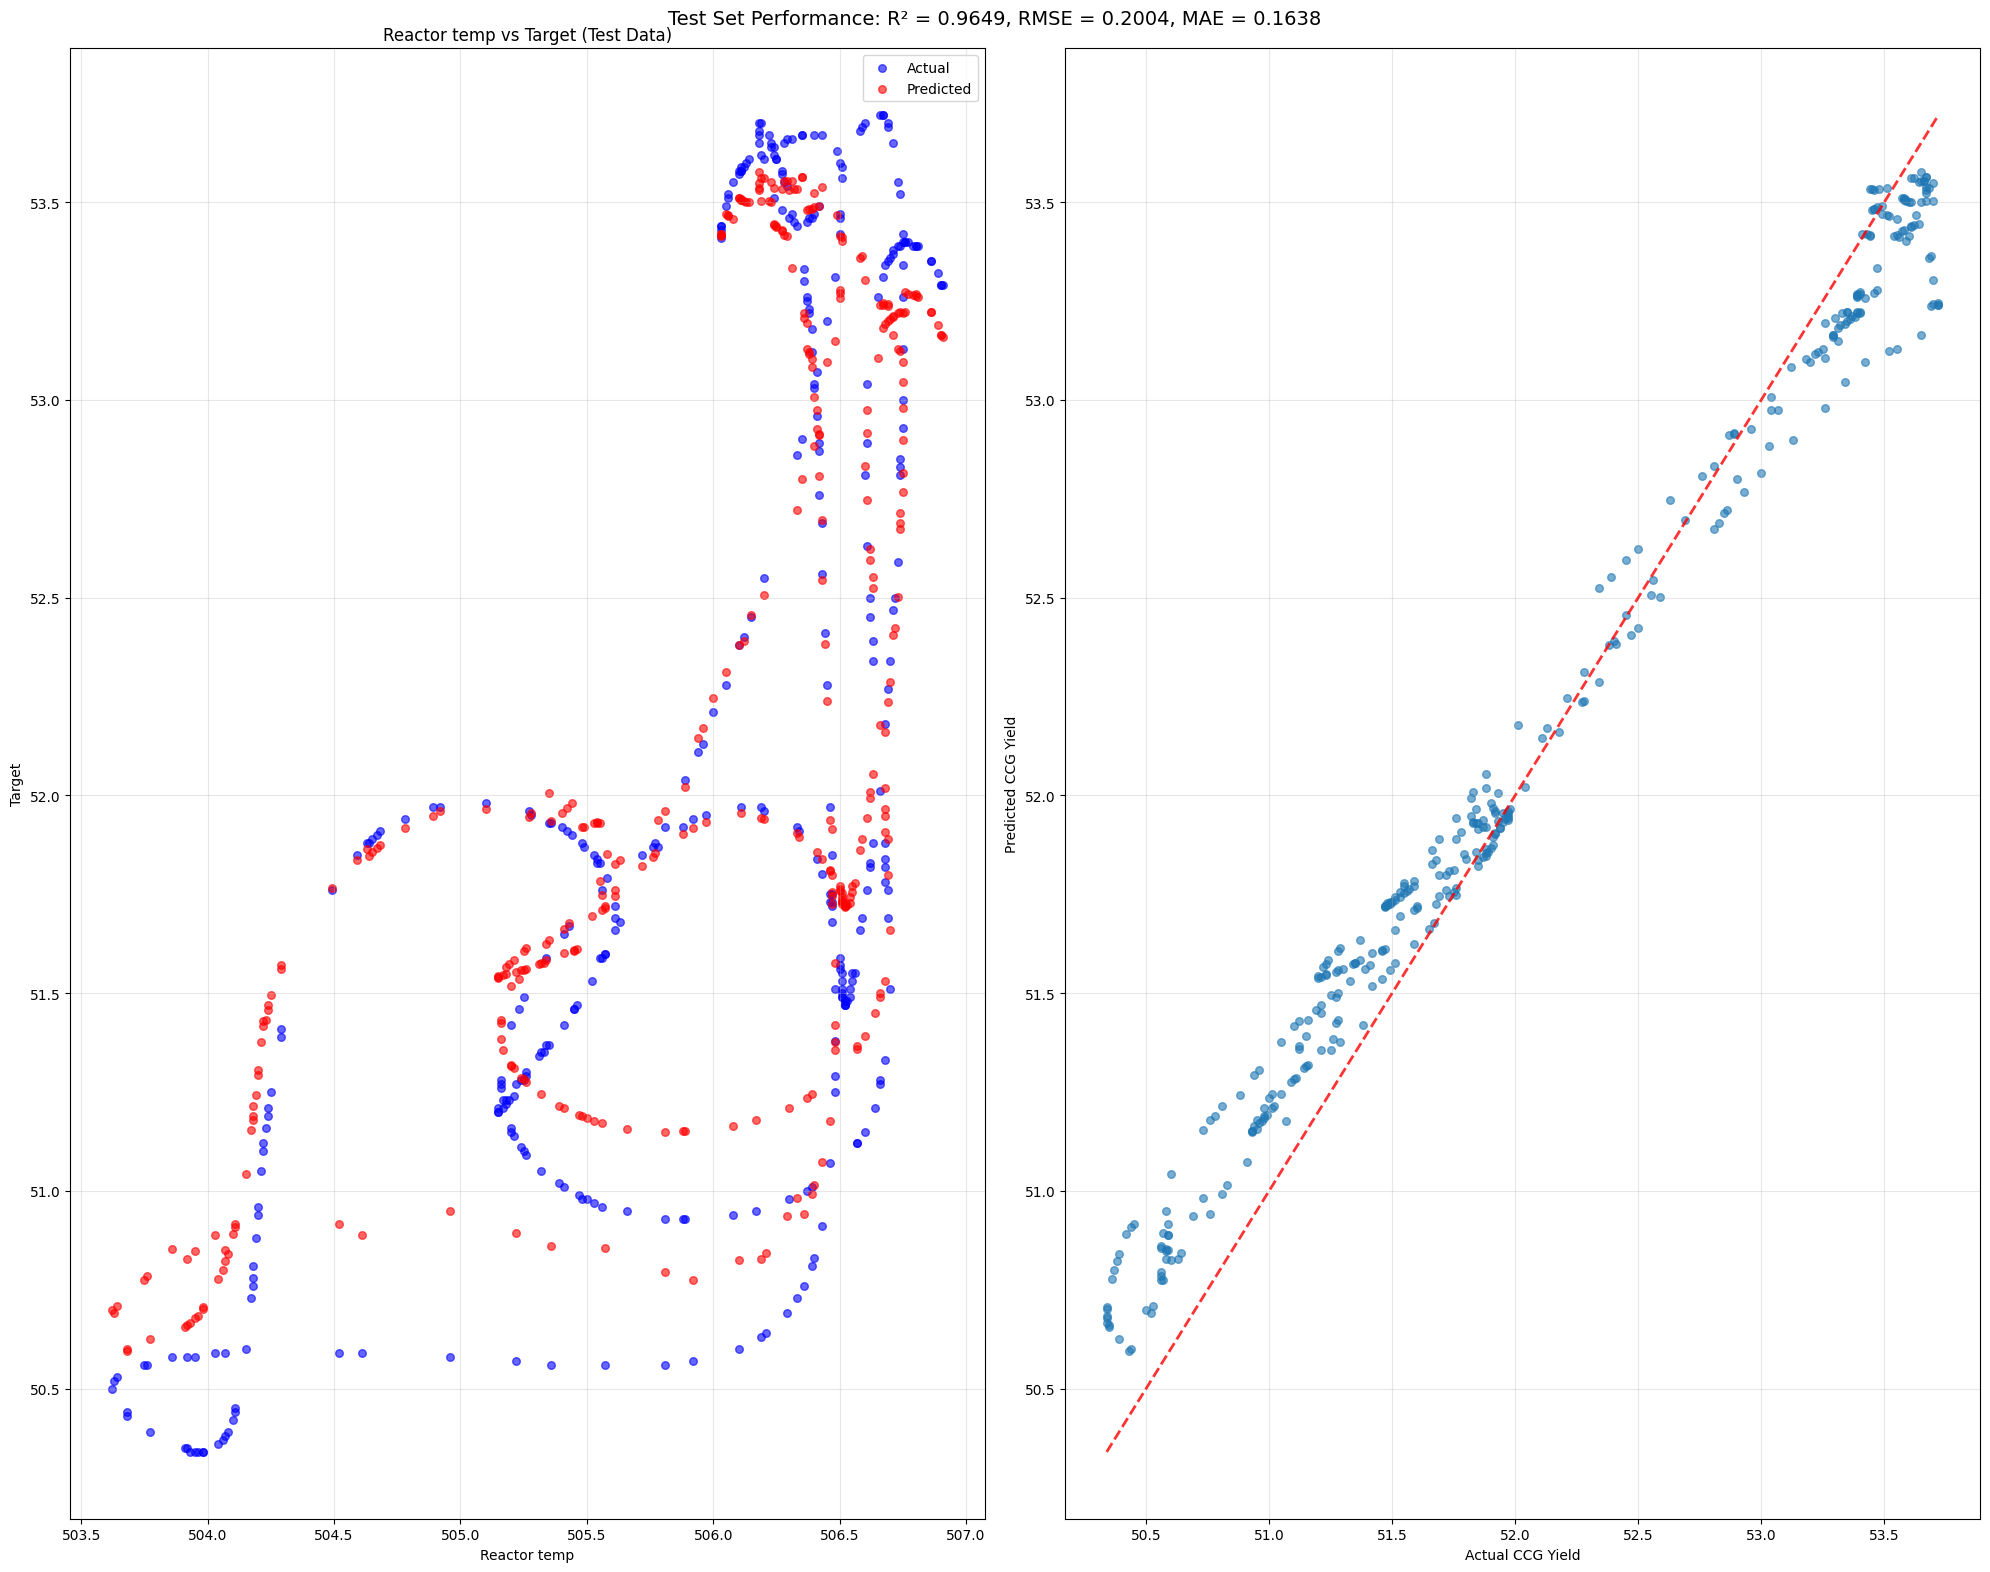


📊 Test Set Metrics:
   R²: 0.9649
   RMSE: 0.2004
   MAE: 0.1638
   Data points: 368

=== Plotting Test Set Predictions ===


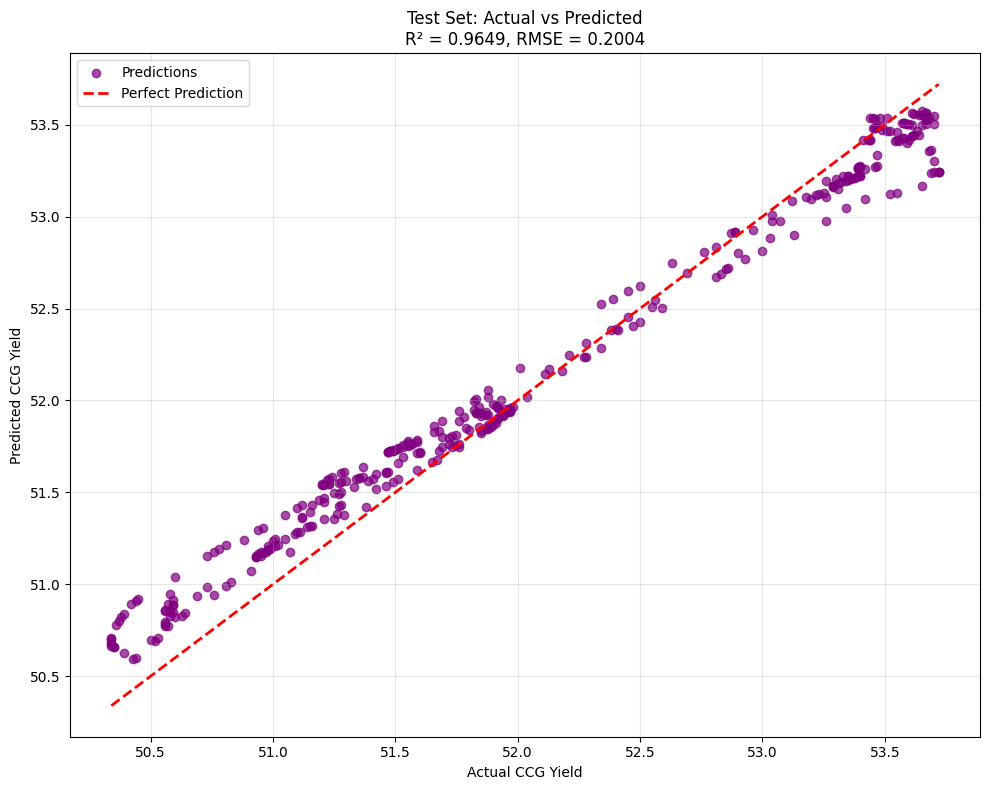

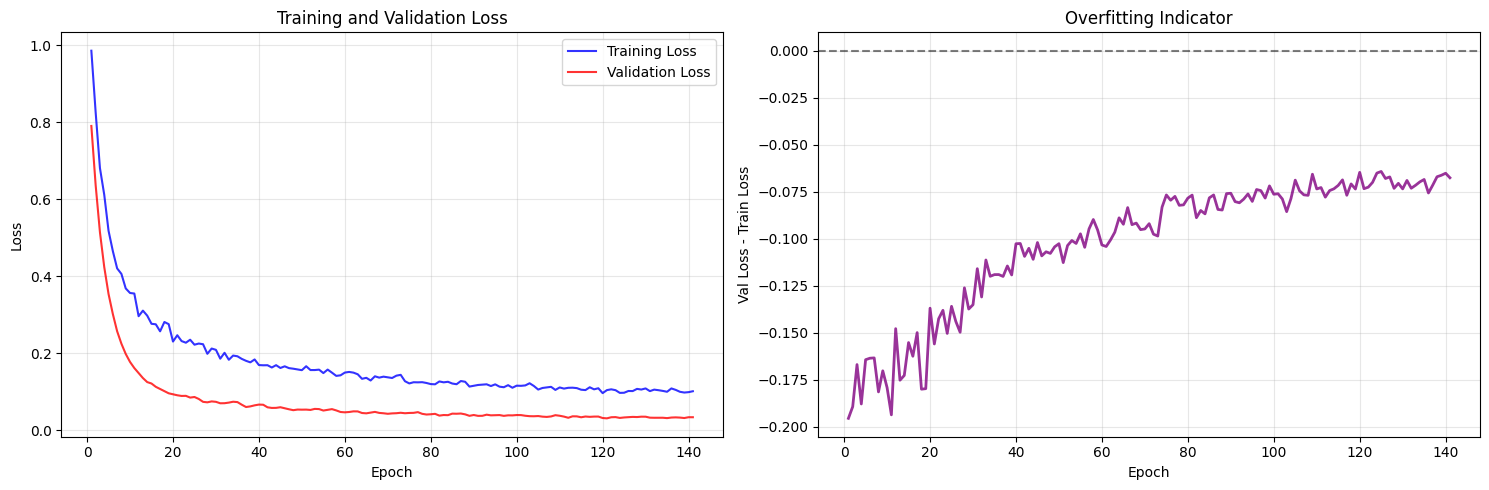

In [6]:
# Initialize
mlp = MLPModelManager()

# Load your data
# csv_path = r'D:\python-workspace\.venv\Notebooks\alladdedjulycut_cleanminimaxi_denoised.csv'
csv_path = r'D:\python-workspace\.venv\Notebooks\Gaussian_denoised50_final.csv'
X, y = mlp.load_data(csv_path, 'CCG Yield', 
                     features_to_drop=[
    # 'Date',
    #                       'Conversion %',
# 'Feed Temp',
# 'Cat Cir rate',
# # 'C/O Ratio',
# 'OVHD Temp',
# 'TCR flow',
# 'Atomizer Flow',
# # 'Reactor temp',
# # 'feed flow',
# 'stab reflux',
# # 'stab ovhd temp',
# 'stripping steam',
# 'Dense phase temp',
# 'UOPK',
'Total arom',
'Feed FBP',
'Feed density',
# 'CCG FBP'
# 'Aniline',
# 'RI'
                                       ])

# Set training parameters
params = {
    'hidden_sizes': [64, 32],
    'dropout_rate': 0.4,
    'learning_rate': 0.0001,
    'batch_size': 32,
    'epochs': 400
}

# Train with K-fold CV
results = mlp.train_model(X, y, params, k_folds=10)

print(f"After training - X_test: {type(mlp.X_test)}")
print(f"After training - y_test: {type(mlp.y_test)}")

mlp.set_feature_ranges({
    'Reactor temp': {'min': 490, 'max': 510},
    'Dense phase temp': {'min': 620, 'max': 650},
    'UOPK' : {'min': 11.6, 'max': 12},
    # 'Total arom': {'min': 12, 'max': 16}
})

# Plot specific feature
mlp.plot_test_performance(feature_name='Reactor temp')

predictions = mlp.plot_test_predictions()

# mlp.plot_feature_vs_target(X, y, 'Reactor temp')

# mlp.plot_test_predictions(X_test, y_test)

mlp.plot_training_curves()

# prediction = mlp.predict_one({
# 'Feed Temp':198,
# 'Cat Cir rate':7.2,
# 'C/O Ratio':10.1,
# 'OVHD Temp':124,
# 'TCR flow':3530,
# 'Atomizer Flow':25,
# 'Reactor temp':507,
# 'feed flow':810,
# 'stab reflux':323,
# 'stab ovhd temp':56,
# 'stripping steam':20.1,
# 'Dense phase temp':634,
# 'Column bottom temp':339,
# 'Rebolier temp':154,
# 'CRC':0.52,
# 'CCR':0.97,
# 'Total arom':89,
# 'Feed FBP':592
# })
# print(f'Prediction: {prediction}')


In [3]:
mlp.plot_test_performance()

🎯 Plotting TEST SET performance using stored data
❌ Feature 'None' not found.
Available features: ['Feed Temp', 'C/O Ratio', 'Reactor temp', 'Feed flow', 'Stab ovhd temp', 'Dense phase temp', 'UOPK', 'CCG FBP']


In [4]:
prediction = mlp.predict_one({
'Feed Temp':250,
'C/O Ratio':11,
'Reactor temp':507,
'Feed flow':800,
'Stab ovhd temp':57,
'Dense phase temp':645,
'UOPK':12,
'CCG FBP': 200
}
,clip_features=False
)
print(f'Prediction: {prediction}')

⚠️  Warning: Some features are outside training data range!
   Feed flow: 800.0000 (training range: [831.5500, 1568.4700])
   ⚠️  Predictions may be unreliable for out-of-range values!
   💡 Set clip_features=True to automatically clip to training range
Prediction: 51.49704360961914


In [5]:
# # 1. นำเข้าไลบรารี joblib
# from joblib import dump
# from sklearn.neural_network import MLPRegressor
# from sklearn.preprocessing import StandardScaler # สมมติว่าใช้ StandardScaler

# # --- สมมติฐาน: ออบเจกต์เหล่านี้ได้รับการฝึก (trained) มาแล้ว ---
# # model_mlp คือโมเดล MLPRegressor ที่ผ่านการฝึกแล้ว
# # model_mlp = MLPRegressor(max_iter=500, random_state=42) 
# # # scaler_X คือ StandardScaler ที่ fit กับข้อมูล X
# # scaler_X = StandardScaler() 
# # # scaler_y คือ StandardScaler ที่ fit กับข้อมูล y
# # scaler_y = StandardScaler()

# # 2. จัดโครงสร้างออบเจกต์ที่จะบันทึก (คล้ายกับการใช้ pickle)
# model_package = {
#     'model': mlp.model,         # โมเดล MLPRegressor ที่ฝึกแล้ว
#     'scaler_X': mlp.scaler_X,       # Scaler สำหรับ Feature X
#     'scaler_y': mlp.scaler_y        # Scaler สำหรับ Target Y
# }

# # 3. บันทึก (Save) โดยใช้ joblib.dump
# # joblib.dump(value, filename)
# filename = 'mlp_model_package.joblib'
# dump(model_package, filename)

# print(f"บันทึกโมเดลและ Scaler ลงในไฟล์ '{filename}' เรียบร้อยแล้ว")

# print("✓ MLP components saved!")